In [49]:
import sys
from typing import Any, Dict, Optional
from pathlib import Path

import numpy as np

from SysSimX.core.base import CoSimComponent
from SysSimX.core.port import PortSpec, PortType
from SysSimX.core.events import EventLocator, Event

from SysSimX.system.connection import EventConnection
from SysSimX.system.system import System

from SysSimX.components.fmu_comp import FMUComponent

from SysSimX.utilities.units import Quantity

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [50]:
class HybridSource(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * t
    Used for testing event indicators and zero-crossing detection.
    """
    
    def __init__(self, name: str, x0: float = 0.0, velocity: float = 1.0):
        super().__init__(name, group='Source')
        self.x0 = x0
        self.v = velocity
        self.x = x0
        self._t0 = None
        
    def _initialize_component(self, t0: float) -> None:
        self._t0 = t0
        self.x = self.x0
        
        self.output_specs.update({
            "x": PortSpec(name="x", type=PortType.REAL, direction="out", unit="m", description="Position"),
            "v": PortSpec(name="v", type=PortType.REAL, direction="out", unit="m/s", description="Velocity")
        })
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self._t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(Quantity(self.x, "m"), t=t)
        self.outputs["v"].set(Quantity(self.v, "m/s"), t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": Quantity(self.x, "m")}
    
    def snapshot_state(self):
        snapshot = {"t": self.t, "x": self.x, "v": self.v}
        return snapshot
    
    def restore_state(self, snapshot) -> None:
        self.t = snapshot["t"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

In [51]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * t
    Used for testing event indicators and zero-crossing detection.
    """
    
    def __init__(self, name: str, x0: float = 0.0, velocity: float = 1.0):
        super().__init__(name, group="Listener")
        self.v = velocity
        self.x = x0
        
    def _initialize_component(self, t0: float) -> None:
        
        self.output_specs.update({
            "x": PortSpec(name="x", type=PortType.REAL, direction="out", unit="m", description="State variable")
        })
        self.input_specs.update({
            "vel_invert": PortSpec(name="vel_invert", type=PortType.EVENT, direction="in", description="Event input to switch velocity")
        })
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x += self.v * dt
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(Quantity(self.x, "m"), t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": Quantity(self.x, "m")}
    
    def snapshot_state(self):
        snapshot = {"t": self.t, "x": self.x, "v": self.v}
        return snapshot
    
    def restore_state(self, snapshot) -> None:
        self.t = snapshot["t"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def _handle_events_internal(self, event_names, t):
        self.v = -self.v
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

In [52]:
src_comp = HybridSource(name="Source", x0=-0.66, velocity=2)

def event_indicator_function(comp: HybridSource) -> float:
    return comp.x
event = Event(name="trigger", source=src_comp.name, direction=1)
src_comp.initialize(t0=0.0)
src_comp.add_event_indicator(event.name, event_indicator_function, direction=event.direction)

listener_comp = HybridListener(name="Listener", x0=0.0, velocity=1.0)
listener_comp.initialize(t0=0.0)
listener_comp.subscribe_event(event=event)

system = System(name="Simple Hybrid Test System")
system.add_component(src_comp)
system.add_component(listener_comp)
connection = EventConnection(src_comp=src_comp.name, src_port=src_comp.output_specs['trigger'].name,
                             dst_comp=listener_comp.name, dst_port=listener_comp.input_specs['vel_invert'].name)
system.add_event_connection(connection)

system.initialize(t0=0.0)

In [53]:
system.event_listeners

[<CoSimComponent name='Listener'>]

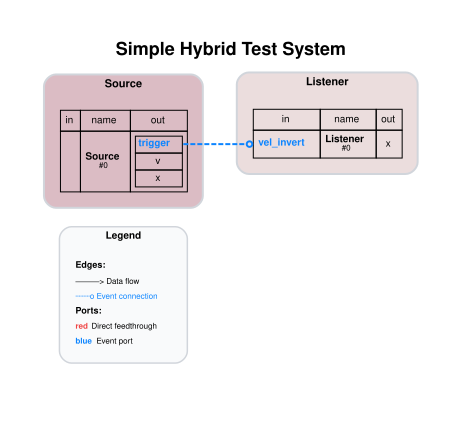

In [54]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [55]:
system.run(t0=0.0, tf=1.0, dt = 0.05)
system.history.get_all_event_histories()


Event(s) detected in interval [0.30000000, 0.35000000]
Located at t=0.33000000
Events: [('Source', 'trigger')]



{('Source', 'trigger'): [0.3300000011920926]}

In [56]:
time_src, data_src = src_comp.get_history_arrays()
x_src = data_src['x']
time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener['x']

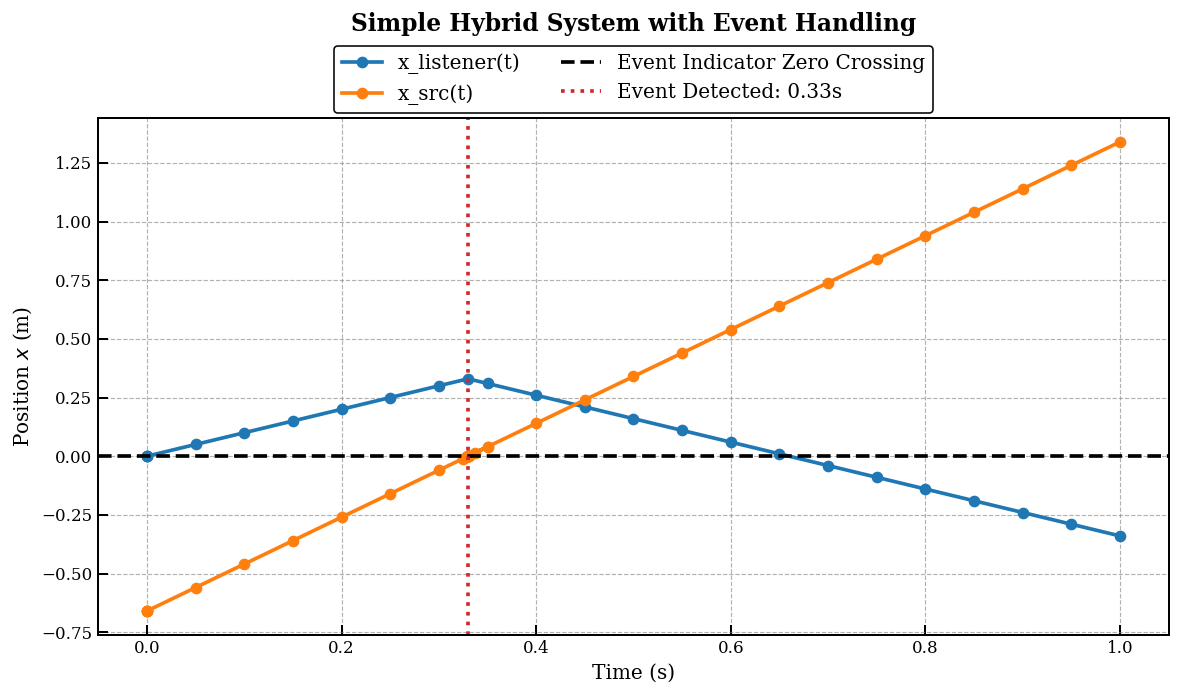

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(time_listener, x_listener, label='x_listener(t)', color='tab:blue', marker='o', linestyle='-')
plt.plot(time_src, x_src, label='x_src(t)', color='tab:orange', marker='o', linestyle='-')
plt.axhline(0, color='black', linestyle='--', label='Event Indicator Zero Crossing')
for event_time in system.history.get_all_event_histories()[(src_comp.name, event.name)]:
    plt.axvline(event_time, color='tab:red', linestyle=':', label=f'Event Detected: {event_time:.2f}s')
plt.title('Simple Hybrid System with Event Handling', fontsize=14, fontweight='bold', y= 1.15)
plt.xlabel('Time (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.16))
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_event_handling.svg')
plt.show()

-------------------

## Recommendations for Improved Testing

### Fix Component Implementations:
1. **HybridSource** - Include `_t0` and `x0` in snapshot/restore
2. **HybridListener** - Store `self.x0 = x0` in `__init__`

### Additional Test Cases Needed:
1. **Multiple events**: Test with 2+ zero crossings in one simulation
2. **Simultaneous events**: Two components with events at same time
3. **Data coupling**: Connect source output to listener input to test frozen inputs
4. **Algebraic loops**: Add components with algebraic coupling + events
5. **Event frequency**: Test events in quick succession (stress test bisection)
6. **Edge cases**: Event exactly at t=0, t=tf, or on step boundaries